This notebook records the creation of the `SHENDURE_BOUNDS` preset object and some plots illustrating modeling choices.

Setup.

In [16]:
import scMPRAforge as scm
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

Load shendure ortho object.

In [2]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v3"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
primordial=scm.ortho.load(client,path,name)

Create the bounds

In [3]:
shendure_bounds=scm.Bounds.from_ortho(primordial)

Let's make some plots showing why we chose nb:

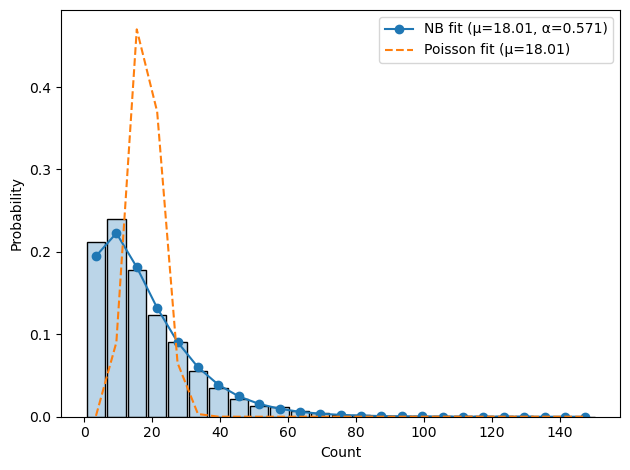

In [22]:
shendure_bounds.transfection_model.plot()

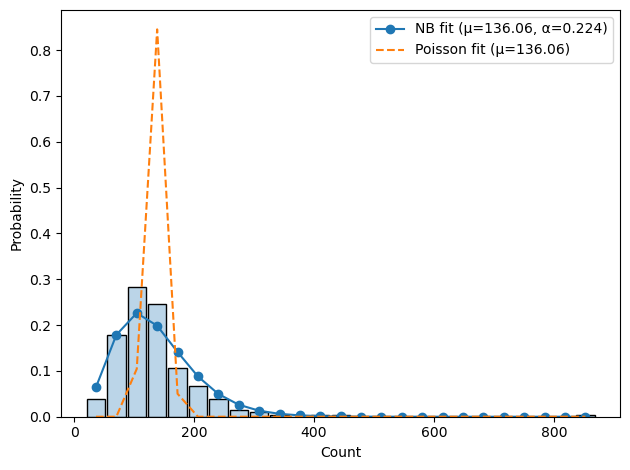

In [23]:
shendure_bounds.library_model.plot()

In [8]:
import seaborn as sns

<Axes: ylabel='Count'>

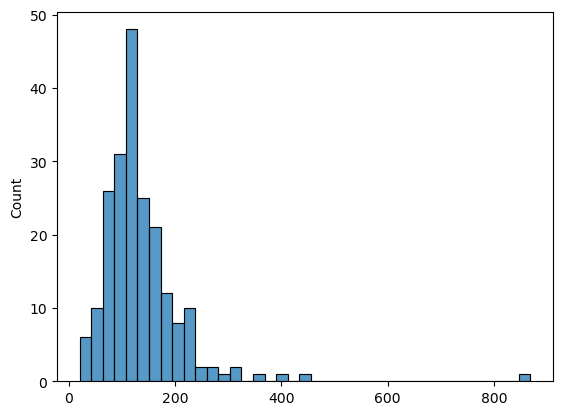

Now let's save the object:

In [7]:
shendure_bounds.to_tgz("scMPRAforge/presets/shendure_bounds.tgz")

In [6]:
cluster.close()